In [7]:
#  tools we will be needing for the project
from ucimlrepo import fetch_ucirepo 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# # here we are fetching wine quality dataset firectely form UCI repository using 186 as ID
wine_quality = fetch_ucirepo(id=186) 
seed = 47259885  # this helps getting the same results every time we run it. It is imp that our numbers dont get chnaged for our report.

X_raw = wine_quality.data.features   # here we are pulling out chemical deatrures and the quality scores.
y_raw = wine_quality.data.targets

# we are using standardscaler to make sure that every feature has a mean of 0 and a var of 1. It would perform poorely without this
scaler = StandardScaler()
X = scaler.fit_transform(X_raw.to_numpy())
y = y_raw.to_numpy().ravel() 

# we split our data into three piles: traning 60% validation 20% and testing 20%
X_tr, X_temp, y_tr, y_temp = train_test_split(X, y, test_size=0.40, random_state=seed, shuffle=True)
X_val, X_te, y_val, y_te = train_test_split(X_temp, y_temp, test_size=0.50, random_state=seed, shuffle=True)

print(f"Dataset loaded. Training on {X_tr.shape[0]} samples.")
print(f"Target quality scores found: {np.unique(y)}")

Dataset loaded. Training on 3898 samples.
Target quality scores found: [3 4 5 6 7 8 9]


In [9]:
# Now we will be testing complexity: how many layers do we need?
# (5,) = 1 layer of 5 neurons this is relatively a simple model. it can cause underfitting
# (100, 50) = 2 layers this a complex model it can overfit
configs = [(5,), (20,), (50,), (100,), (100, 50)]
results = []

print("Starting training experiments... please wait.")

for config in configs:
    # random_state=seed ensures we can reproduce these exact numbers
    mlp = MLPClassifier(hidden_layer_sizes=config, max_iter=1500, random_state=seed)   # here max_iter = 1500 to give model enough time to find best patterns
    mlp.fit(X_tr, y_tr)
    
    tr_acc = accuracy_score(y_tr, mlp.predict(X_tr))
    val_acc = accuracy_score(y_val, mlp.predict(X_val))
    
    results.append({'Layer Config': str(config), 'Train Acc': tr_acc, 'Val Acc': val_acc})
    print(f"Finished config {config} | Val Acc: {val_acc:.4f}")

# displaying as a table. help for report :)
df_results = pd.DataFrame(results)
print("\n--- NEURAL NETWORK RESULTS TABLE ---")
print(df_results)

Starting training experiments... please wait.
Finished config (5,) | Val Acc: 0.5620
Finished config (20,) | Val Acc: 0.5727
Finished config (50,) | Val Acc: 0.5651
Finished config (100,) | Val Acc: 0.5912
Finished config (100, 50) | Val Acc: 0.5627

--- NEURAL NETWORK RESULTS TABLE ---
  Layer Config  Train Acc   Val Acc
0         (5,)   0.549256  0.561971
1        (20,)   0.586968  0.572748
2        (50,)   0.635711  0.565050
3       (100,)   0.696511  0.591224
4    (100, 50)   0.856337  0.562741


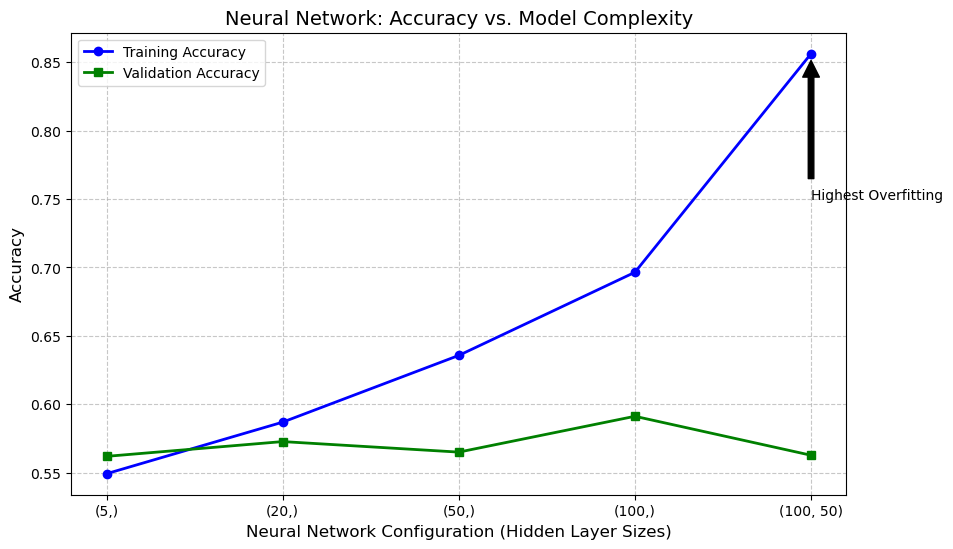

In [12]:
import matplotlib.pyplot as plt

# data from the results table
configs = ['(5,)', '(20,)', '(50,)', '(100,)', '(100, 50)']
train_accs = [0.5492, 0.5869, 0.6357, 0.6965, 0.8563]
val_accs = [0.5619, 0.5727, 0.5650, 0.5912, 0.5627]

plt.figure(figsize=(10, 6))

# plotting the lines
plt.plot(configs, train_accs, marker='o', label='Training Accuracy', color='blue', linewidth=2)
plt.plot(configs, val_accs, marker='s', label='Validation Accuracy', color='green', linewidth=2)

# adding details to look good 
plt.xlabel('Neural Network Configuration (Hidden Layer Sizes)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Neural Network: Accuracy vs. Model Complexity', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# highlight the overfitting at the end
plt.annotate('Highest Overfitting', xy=('(100, 50)', 0.8563), xytext=('(100, 50)', 0.75),
             arrowprops=dict(facecolor='black', shrink=0.05))

# saving the figure
plt.savefig('nn_complexity_graph.png')
plt.show()

FINAL TEST ACCURACY: 0.5715


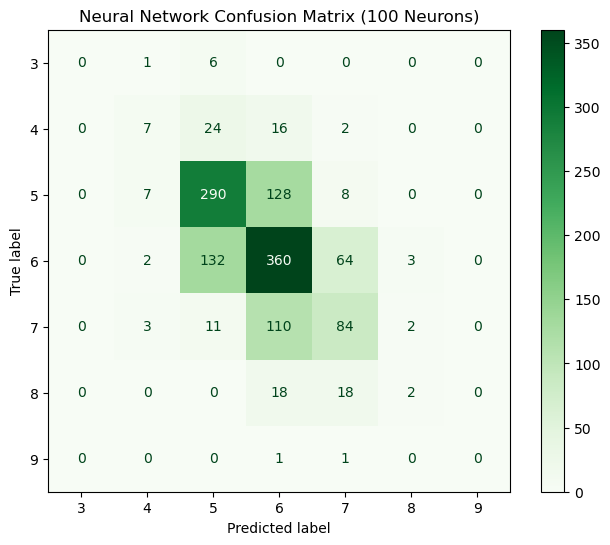


Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         7
           4       0.35      0.14      0.20        49
           5       0.63      0.67      0.65       433
           6       0.57      0.64      0.60       561
           7       0.47      0.40      0.43       210
           8       0.29      0.05      0.09        38
           9       0.00      0.00      0.00         2

    accuracy                           0.57      1300
   macro avg       0.33      0.27      0.28      1300
weighted avg       0.55      0.57      0.56      1300



In [11]:
# Now we will be Training on the winning model which is with 100 neurons
best_mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1500, random_state=seed)
best_mlp.fit(X_tr, y_tr)

# This is the finla score on the test set 
test_preds = best_mlp.predict(X_te)
print(f"FINAL TEST ACCURACY: {accuracy_score(y_te, test_preds):.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_te, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(cmap='Greens', ax=ax)
plt.title("Neural Network Confusion Matrix (100 Neurons)")
plt.savefig('nn_confusion_matrix.png') # This saves the image and helps for the report :)
plt.show()

# detailed report to see if we caught the rare wines
print("\nClassification Report:")
print(classification_report(y_te, test_preds, zero_division=0))